# HW: Imbalanced data, Evaluation metrics, Cross validation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


繳交網址：https://forms.gle/gjfsbxxtqrSKbuVV7 <br>
繳交期限：4/11 23:55 <br>
重複繳交以最新的做計算

HW-1

作業說明：請自行定義一個函式 def split_data(): 切分imbalanced data<br>
情境：一份DF有N個類別，放入split_data()之後自動切出x_train, y_train, x_test, y_test，<br>
其中x_train, y_train, x_test, y_test內比例與DF中各類別比例需相同。<br>
函式input：自行定義<br>
函式output：x_train, y_train, x_test, y_test<br>
不可使用from sklearn.model_selection import train_test_split套件，其他皆可使用<br>
<br>
配分方式(總分60)：<br>
1. 按label比例分(得60分)，未按label比例(得40分)

Hint: 可參考Split data to train and test那段<br>
1. 整理不平衡資料時，需要將不同類別的資料單獨拉出來，以方便後續切分資料所使用
2. 創建temp_df存取不同類別的資料，創建out_df存取最終return的資料
3. out_df = pd.concat([out_df, temp_df], axis=0)
3. 檢查是否與raw data的分配比例一樣

In [ ]:
import pandas as pd
input_df = pd.read_csv('HW1_data.csv')

In [ ]:
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

#from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score
from sklearn import preprocessing
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import recall_score, precision_score
from sklearn import svm

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

import random

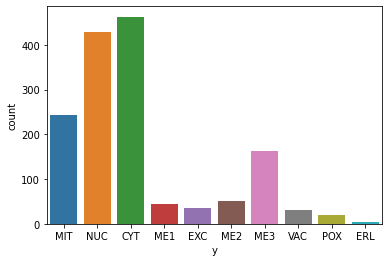

In [ ]:
ax = sns.countplot(x="y", data=input_df )

比例 和 數量 'CYT','ERL','EXC','ME1','ME2','ME3','MIT','NUC','POX','VAC'

In [ ]:
print('CYT y:', sum(input_df['y']=='CYT'))
print('ERL y:', sum(input_df['y']=='ERL'))
print('EXC y:', sum(input_df['y']=='EXC'))
print('ME1 y:', sum(input_df['y']=='ME1'))
print('ME2 y:', sum(input_df['y']=='ME2'))
print('ME3 y:', sum(input_df['y']=='ME3'))
print('MIT y:', sum(input_df['y']=='MIT'))
print('NUC y:', sum(input_df['y']=='NUC'))
print('POX y:', sum(input_df['y']=='POX'))
print('VAC y:', sum(input_df['y']=='VAC'))

print('CYT ratio:', sum(input_df['y']=='CYT')/len(input_df))
print('ERL ratio:', sum(input_df['y']=='ERL')/len(input_df))
print('EXC ratio:', sum(input_df['y']=='EXC')/len(input_df))
print('ME1 ratio:', sum(input_df['y']=='ME1')/len(input_df))
print('ME2 ratio:', sum(input_df['y']=='ME2')/len(input_df))
print('ME3 ratio:', sum(input_df['y']=='ME3')/len(input_df))
print('MIT ratio:', sum(input_df['y']=='MIT')/len(input_df))
print('NUC ratio:', sum(input_df['y']=='NUC')/len(input_df))
print('POX ratio:', sum(input_df['y']=='POX')/len(input_df))
print('VAC ratio:', sum(input_df['y']=='VAC')/len(input_df))

CYT y: 463
ERL y: 5
EXC y: 35
ME1 y: 44
ME2 y: 51
ME3 y: 163
MIT y: 244
NUC y: 429
POX y: 20
VAC y: 30
CYT ratio: 0.3119946091644205
ERL ratio: 0.0033692722371967657
EXC ratio: 0.02358490566037736
ME1 ratio: 0.029649595687331536
ME2 ratio: 0.03436657681940701
ME3 ratio: 0.10983827493261455
MIT ratio: 0.16442048517520216
NUC ratio: 0.2890835579514825
POX ratio: 0.013477088948787063
VAC ratio: 0.02021563342318059


In [ ]:
def split_data(input_df, test_size): # or def split_data(input_x, input_y, test_size)
    
    train_ratio = test_size
    num_data = len(input_df)
    train_len = int(num_data * train_ratio)
    test_len = num_data - train_len
    
    init_list = list(range(num_data))
    random.shuffle(init_list)
    
    train_df =  pd.DataFrame()
    test_df = pd.DataFrame()
    
    count = 0
    for i in init_list:
        if count < train_len:
            train_df = pd.concat([train_df,pd.DataFrame(input_df.iloc[i]).T], axis=0).reset_index(drop=True)
            count+=1            
        else:
            test_df = pd.concat([test_df,pd.DataFrame(input_df.iloc[i]).T], axis=0).reset_index(drop=True)
            count+=1
            
    x_train = train_df.drop(['y'],axis=1)
    y_train = train_df['y']
    x_test = test_df.drop(['y'],axis=1)
    y_test = test_df['y']
    
    le = LabelEncoder()
    le.fit(['CYT','ERL','EXC','ME1','ME2','ME3','MIT','NUC','POX','VAC'])
    y_train = le.transform(y_train)
    y_test = le.transform(y_test)
    return x_train, y_train, x_test, y_test

In [ ]:
train_ratio = 0.8
num_data = len(input_df)
train_len = int(num_data * train_ratio)
test_len = num_data - train_len

創建與資料比數一樣的list [0~n]
創建空的dataframe

當count<train_len，將train_df與pd.DataFrame(wilt_all.iloc[i]).T concat在一起

當count>train_len，將test_df與pd.DataFrame(wilt_all.iloc[i]).T concat在一起

In [ ]:
init_list = list(range(num_data))
random.shuffle(init_list)

train_df = pd.DataFrame()
test_df = pd.DataFrame()

count=0
for i in init_list:
    if count < train_len:
        train_df = pd.concat([train_df, pd.DataFrame(input_df.iloc[i]).T], axis=0).reset_index(drop=True)
        count+=1
    else:
        test_df = pd.concat([test_df, pd.DataFrame(input_df.iloc[i]).T], axis=0).reset_index(drop=True)
        count+=1

In [ ]:
y_train = train_df['y']
x_train = train_df.drop(['y'],axis=1)
y_test = test_df['y']
x_test = test_df.drop(['y'],axis=1)

In [ ]:
le = LabelEncoder()
le.fit(['CYT','ERL','EXC','ME1','ME2','ME3','MIT','NUC','POX','VAC'])
y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [ ]:
print('y_train y CYT:', sum(y_train==0))
print('y_train y ERL:', sum(y_train==1))
print('y_train y EXC:', sum(y_train==2))
print('y_train y ME1:', sum(y_train==3))
print('y_train y ME2:', sum(y_train==4))
print('y_train y ME3:', sum(y_train==5))
print('y_train y MIT:', sum(y_train==6))
print('y_train y NUC:', sum(y_train==7))
print('y_train y POX:', sum(y_train==8))
print('y_train y VAC:', sum(y_train==9))
print('-------------------------------------------------')
print('y_train ratio CYT:', sum(y_train==0)/len(y_train))
print('y_train ratio ERL:', sum(y_train==1)/len(y_train))
print('y_train ratio EXC:', sum(y_train==2)/len(y_train))
print('y_train ratio ME1:', sum(y_train==3)/len(y_train))
print('y_train ratio ME2:', sum(y_train==4)/len(y_train))
print('y_train ratio ME3:', sum(y_train==5)/len(y_train))
print('y_train ratio MIT:', sum(y_train==6)/len(y_train))
print('y_train ratio NUC:', sum(y_train==7)/len(y_train))
print('y_train ratio POX:', sum(y_train==8)/len(y_train))
print('y_train ratio VAC:', sum(y_train==9)/len(y_train))
print('-------------------------------------------------')
print('y_test y CYT:', sum(y_test==0))
print('y_test y ERL:', sum(y_test==1))
print('y_test y EXC:', sum(y_test==2))
print('y_test y ME1:', sum(y_test==3))
print('y_test y ME2:', sum(y_test==4))
print('y_test y ME3:', sum(y_test==5))
print('y_test y MIT:', sum(y_test==6))
print('y_test y NUC:', sum(y_test==7))
print('y_test y POX:', sum(y_test==8))
print('y_test y VAC:', sum(y_test==9))
print('-------------------------------------------------')
print('y_test ratio CYT:', sum(y_test==0)/len(y_test))
print('y_test ratio ERL:', sum(y_test==1)/len(y_test))
print('y_test ratio EXC:', sum(y_test==2)/len(y_test))
print('y_test ratio ME1:', sum(y_test==3)/len(y_test))
print('y_test ratio ME2:', sum(y_test==4)/len(y_test))
print('y_test ratio ME3:', sum(y_test==5)/len(y_test))
print('y_test ratio MIT:', sum(y_test==6)/len(y_test))
print('y_test ratio NUC:', sum(y_test==7)/len(y_test))
print('y_test ratio POX:', sum(y_test==8)/len(y_test))
print('y_test ratio VAC:', sum(y_test==9)/len(y_test))

y_train y CYT: 372
y_train y ERL: 5
y_train y EXC: 30
y_train y ME1: 35
y_train y ME2: 42
y_train y ME3: 127
y_train y MIT: 196
y_train y NUC: 339
y_train y POX: 15
y_train y VAC: 26
-------------------------------------------------
y_train ratio CYT: 0.3133951137320977
y_train ratio ERL: 0.004212299915754001
y_train ratio EXC: 0.02527379949452401
y_train ratio ME1: 0.02948609941027801
y_train ratio ME2: 0.03538331929233361
y_train ratio ME3: 0.10699241786015164
y_train ratio MIT: 0.16512215669755687
y_train ratio NUC: 0.2855939342881213
y_train ratio POX: 0.012636899747262006
y_train ratio VAC: 0.02190395956192081
-------------------------------------------------
y_test y CYT: 91
y_test y ERL: 0
y_test y EXC: 5
y_test y ME1: 9
y_test y ME2: 9
y_test y ME3: 36
y_test y MIT: 48
y_test y NUC: 90
y_test y POX: 5
y_test y VAC: 4
-------------------------------------------------
y_test ratio CYT: 0.3063973063973064
y_test ratio ERL: 0.0
y_test ratio EXC: 0.016835016835016835
y_test ratio ME

In [ ]:
x_train, y_train, x_test, y_test = split_data(input_df, 0.2)
print(x_train)
print(y_train)
print(x_test)
print(y_test)

    Sequence_Name   mcg   gvh   alm   mit  erl pox   vac   nuc
0      PCNA_YEAST  0.49  0.71  0.54  0.13  0.5   0  0.58  0.22
1      GBA1_YEAST   0.3   0.5  0.47  0.11  0.5   0  0.46  0.22
2      PIR1_YEAST  0.77  0.78  0.51  0.28  0.5   0  0.33  0.22
3      CYC1_YEAST  0.46  0.54  0.71  0.15  0.5   0  0.59  0.22
4      GSP1_YEAST  0.58  0.48  0.56   0.1  0.5   0  0.46  0.25
..            ...   ...   ...   ...   ...  ...  ..   ...   ...
291    THIL_YEAST  0.54  0.65  0.49  0.34  0.5   0  0.52  0.22
292    ARO1_YEAST  0.54  0.48  0.44  0.08  0.5   0  0.52  0.27
293    STL1_YEAST  0.36   0.5  0.39  0.23  0.5   0   0.5  0.22
294    PDS1_YEAST  0.37  0.42   0.6  0.13  0.5   0  0.51  0.22
295    VPH1_YEAST  0.57  0.54  0.32  0.15  0.5   0  0.52  0.25

[296 rows x 9 columns]
[7 0 2 6 7 0 7 5 8 6 0 6 7 7 0 2 0 3 6 0 6 7 9 7 6 5 0 0 0 8 7 7 7 0 0 3 7
 6 7 0 0 2 6 0 0 5 7 7 4 6 0 0 5 7 0 0 6 7 6 6 5 5 5 7 0 7 0 6 6 7 2 4 6 0
 2 7 0 6 6 3 6 5 0 8 5 3 6 1 9 7 7 0 7 7 9 7 3 7 0 0 7 0 6 0 6 7 0 5 6

# 新增區段 利用train_test_split將資料切分成train, test

In [ ]:
split_data(input_df,0.8)

(     Sequence_Name   mcg   gvh   alm   mit  erl pox   vac   nuc
 0       PNPP_YEAST  0.38  0.62  0.52  0.14  0.5   0  0.53  0.22
 1       VP45_YEAST  0.46  0.52  0.51  0.13  0.5   0  0.47  0.22
 2       YIG3_YEAST  0.34  0.24  0.51  0.15  0.5   0  0.54   0.4
 3       RLA2_YEAST  0.69  0.54  0.55  0.23  0.5   0  0.73  0.22
 4       HAP4_YEAST  0.56  0.57  0.63  0.39    1   0  0.59   0.4
 ...            ...   ...   ...   ...   ...  ...  ..   ...   ...
 1182    MFA2_YEAST  0.46  0.42   0.6  0.21  0.5   0   0.4  0.22
 1183     TSA_YEAST  0.59  0.64  0.44  0.26  0.5   0   0.5  0.22
 1184    YBC4_YEAST  0.32   0.3  0.57  0.38  0.5   0   0.5  0.25
 1185    CHI1_YEAST  0.82  0.78  0.49  0.23  0.5   0  0.46  0.22
 1186    DKA1_YEAST  0.42   0.5  0.59  0.17  0.5   0  0.51  0.22
 
 [1187 rows x 9 columns],
 array([0, 0, 7, ..., 7, 2, 0]),
     Sequence_Name   mcg   gvh   alm   mit  erl pox   vac   nuc
 0      SYFA_YEAST  0.45   0.4  0.56  0.14  0.5   0  0.54  0.22
 1      ROX3_YEAST  0.43  0.44 

HW-2

作業說明(總分40)： <br>
以def定義N類別的recall function (得20分)<br>
函式input：y_true, y_pred<br>
函式output：recall<br>
以def定義N類別的precision function (得20分)<br>
函式input：y_true, y_pred<br>
函式output：recall<br>
套件皆可使用

reference<br>
https://medium.com/data-science-in-your-pocket/calculating-precision-recall-for-multi-class-classification-9055931ee229

Hint: 可參考Evaluation metrics (HW-2)那段<br>
可以用confusing matrix幫忙計算<br>
可利用from sklearn.metrics import recall_score, precision_score<br>

recall:    array([0.6847, 0.6   , 0.7714, 0.4545, 0.7255, 0.8405, 0.9098, 0.9301,   0.85  , 0.9   ])<br>
precision: array([0.883 , 1.    , 0.7105, 0.6061, 0.6066, 0.7249, 0.8506, 0.8244,   0.68  , 0.871 ])

 Accuracy
 Recall = TP / (TP + FN)

 召回率 (Recall)：正樣本有多少被找出来(召回了多少)

 Precision = TP / (TP + FP)

 精確率 (Precision)：模型認為的正樣本，有多少預測對了(預測的精確性如何)
 
 F1-score = 2 * Precision * Recall / (Precision + Recall)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import recall_score, precision_score,confusion_matrix, accuracy_score
df=pd.read_csv('HW2_data.csv')
y_pred = df['y_pred']
y_true = df['y_true']
le = LabelEncoder()
le.fit(y_true)
y_true = le.transform(y_true)
y_pred = le.transform(y_pred)

In [ ]:
cm = confusion_matrix(df["y_true"], df["y_pred"])
recall = recall_score(df["y_true"], df["y_pred"], average=None)
precision = precision_score(df["y_true"], df["y_pred"], average=None)

In [ ]:
def multi_recall(y_true, y_pred):
  recall = recall_score(y_true, y_pred, average=None)
  return recall

multi_recall(df["y_true"], df["y_pred"])

array([0.68466523, 0.6       , 0.77142857, 0.45454545, 0.7254902 ,
       0.8404908 , 0.90983607, 0.93006993, 0.85      , 0.9       ])

In [ ]:
def multi_precision(y_true, y_pred):
  precision = precision_score(y_true, y_pred, average=None)
  return precision

multi_precision(df["y_true"], df["y_pred"])

array([0.88300836, 1.        , 0.71052632, 0.60606061, 0.60655738,
       0.72486772, 0.85057471, 0.82438017, 0.68      , 0.87096774])